In [1]:
import pandas as pd

# Cargar dataset
df = pd.read_csv("kc_house_data.csv")

# Ver primeras filas
print(df.head())

# Información general
print(df.info())

# Valores nulos
print(df.isnull().sum())

           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

In [3]:
# Estadisticas descriptivas
print(df.describe())

                 id         price      bedrooms     bathrooms   sqft_living  \
count  2.161300e+04  2.161300e+04  21613.000000  21613.000000  21613.000000   
mean   4.580302e+09  5.400881e+05      3.370842      2.114757   2079.899736   
std    2.876566e+09  3.671272e+05      0.930062      0.770163    918.440897   
min    1.000102e+06  7.500000e+04      0.000000      0.000000    290.000000   
25%    2.123049e+09  3.219500e+05      3.000000      1.750000   1427.000000   
50%    3.904930e+09  4.500000e+05      3.000000      2.250000   1910.000000   
75%    7.308900e+09  6.450000e+05      4.000000      2.500000   2550.000000   
max    9.900000e+09  7.700000e+06     33.000000      8.000000  13540.000000   

           sqft_lot        floors    waterfront          view     condition  \
count  2.161300e+04  21613.000000  21613.000000  21613.000000  21613.000000   
mean   1.510697e+04      1.494309      0.007542      0.234303      3.409430   
std    4.142051e+04      0.539989      0.086517    

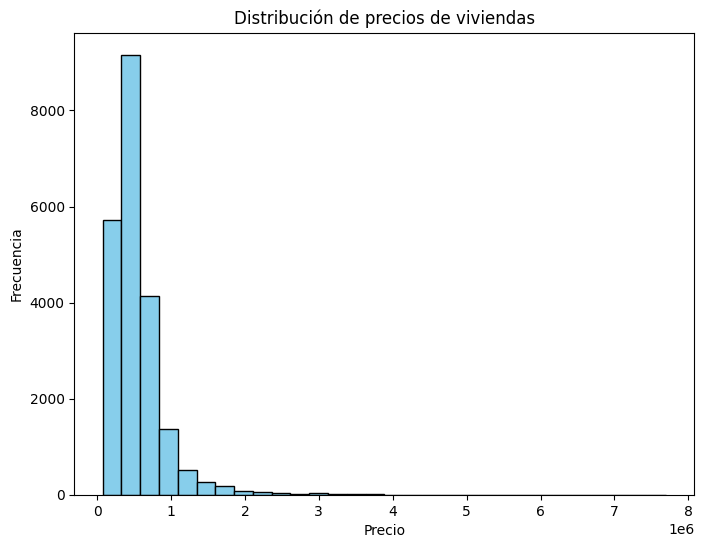

In [5]:
# Histograma de distribución de precios de viviendas
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(df["price"], bins=30, color="skyblue", edgecolor="black")

plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.title("Distribución de precios de viviendas")

plt.show()

El histograma de precios muestra una distribución asimétrica positiva, donde la mayoría de las viviendas presentan precios relativamente bajos o medios, mientras que existe una menor cantidad de propiedades con valores extremadamente altos. Además, se observan posibles valores atípicos correspondientes a viviendas de lujo con precios considerablemente superiores al promedio.

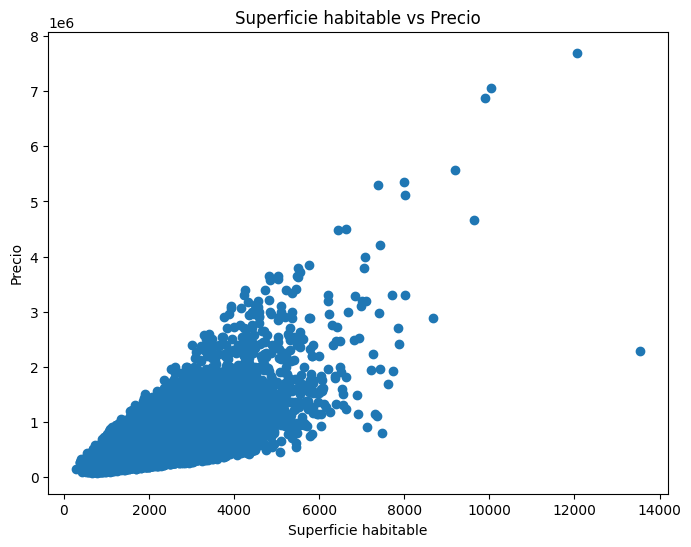

In [7]:
# Scatter superficie vs precio
plt.figure(figsize=(8,6))

plt.scatter(df["sqft_living"], df["price"])

plt.xlabel("Superficie habitable")
plt.ylabel("Precio")

plt.title("Superficie habitable vs Precio")

plt.show()

El gráfico de dispersión muestra una relación positiva entre la superficie habitable de las viviendas (sqft_living) y su precio (price). En general, las propiedades con mayor superficie presentan precios más altos. Además, se observa cierta dispersión en los valores, lo que indica que existen otros factores que también influyen en el precio final de las viviendas. A su vez, se identifican algunos valores atípicos correspondientes a propiedades de gran tamaño y alto valor económico

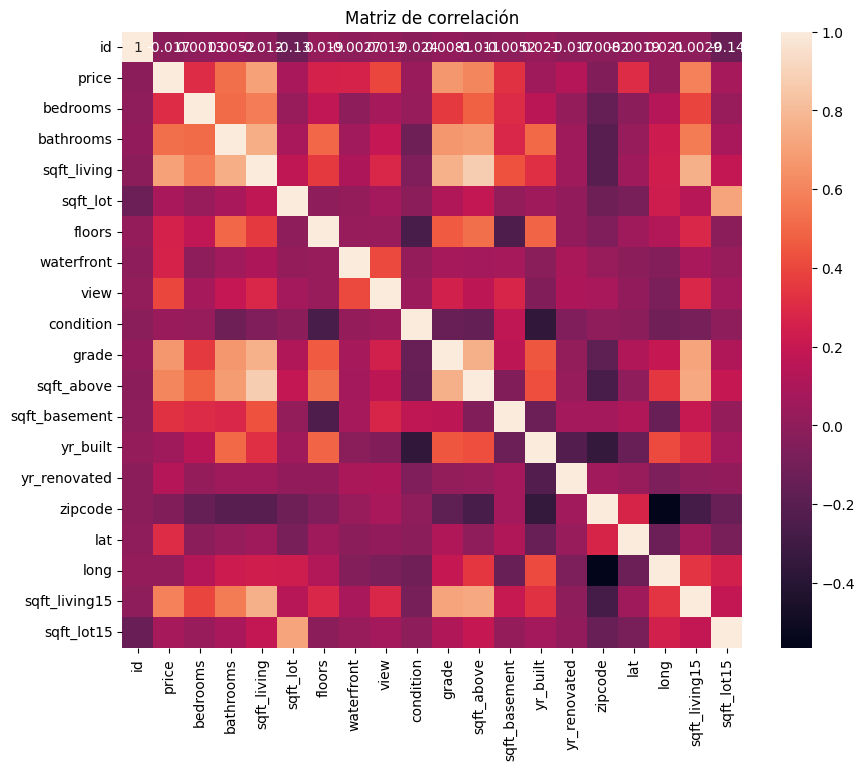

In [9]:
# Matriz de correlación
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Matriz de correlación")

plt.show()

La matriz de correlación permitió identificar las variables con mayor relación respecto al precio de las viviendas (price). Se observó que variables como la superficie habitable (sqft_living), la calidad general de la propiedad (grade) y la cantidad de baños (bathrooms) presentan correlaciones positivas importantes con el precio. Por otro lado, variables como id y zipcode muestran una relación débil, por lo que estas poseen menor relevancia predictiva dentro del modelo de regresión lineal.

In [34]:
# División de datos y entrenamiento del modelo
from sklearn.model_selection import train_test_split
X = df[[
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "floors",
    "grade",
    "yr_built"
]]

y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
# Modelo de Regresión Lineal
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)


LinearRegression()

In [38]:
# Predicciones y evaluación
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = modelo.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 149623.94661137607
R2: 0.608845832555333


El modelo de regresión lineal obtuvo un valor de R² de aproximadamente 0.61, lo que indica que logra explicar el 61% de la variabilidad del precio de las viviendas a partir de las variables seleccionadas. Además, el MAE obtenido muestra que el error promedio en las predicciones es de alrededor de 149 mil dólares. Estos resultados sugieren que el modelo posee una capacidad predictiva moderadamente buena, aunque existen otros factores que también van a terminar influyendo en el valor final de las propiedades.